## CAGR Analysis

The Compound Annual Growth Rate (CAGR) measures the annualized return of each mutual fund over a specified investment horizon.

- 1-year CAGR and 3-year CAGR were calculated directly from NAV history.
- The available NAV data spans approximately 4.4 years, so a full 5-year CAGR cannot be computed from historical NAV values.
- The 5-year return from the provided performance dataset was retained for comparison.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

In [3]:
print(nav.columns)
print(performance.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

In [5]:
nav = nav.sort_values(["amfi_code", "date"]) 

In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

In [7]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')


In [9]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [10]:
nav["daily_return"].isna().sum()

np.int64(40)

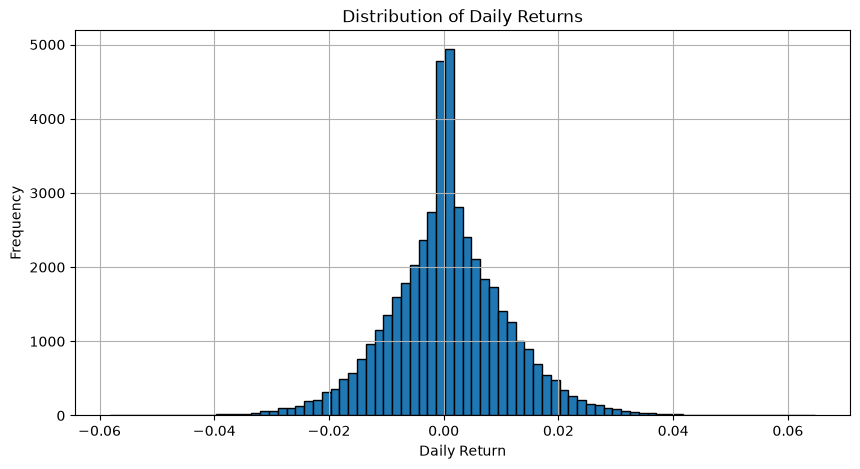

In [11]:
plt.figure(figsize=(10,5))

nav["daily_return"].hist(
    bins=80,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [12]:
print("Skewness :", nav["daily_return"].skew())
print("Kurtosis:", nav["daily_return"].kurt())

Skewness : 0.042677821268501254
Kurtosis: 1.3673122332240242


In [13]:
nav.to_csv("../data/processed/nav_with_returns.csv", index=False)

In [14]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [15]:
def calculate_cagr(nav_df, years):
    results = []

    latest_date = nav_df["date"].max()
    start_date = latest_date - pd.DateOffset(years=years)

    for amfi_code, group in nav_df.groupby("amfi_code"):

        group = group.sort_values("date")

        start_rows = group[group["date"] >= start_date]

        if len(start_rows) == 0:
            continue

        nav_start = start_rows.iloc[0]["nav"]
        nav_end = group.iloc[-1]["nav"]

        cagr = (nav_end / nav_start) ** (1 / years) - 1

        results.append({
            "amfi_code": amfi_code,
            f"CAGR_{years}yr": cagr
        })

    return pd.DataFrame(results)

In [16]:
cagr_1 = calculate_cagr(nav, 1)

In [17]:
cagr_3 = calculate_cagr(nav, 3)

In [18]:
cagr = cagr_1.merge(cagr_3, on="amfi_code", how="outer")

In [19]:
cagr = cagr.merge(
    performance[
        ["amfi_code", "scheme_name", "return_5yr_pct"]
    ],
    on="amfi_code",
    how="left"
)

In [20]:
cagr = cagr.rename(
    columns={
        "return_5yr_pct": "CAGR_5yr_dataset"
    }
)

In [21]:
cagr["CAGR_1yr"] *= 100
cagr["CAGR_3yr"] *= 100

In [22]:
cagr.head()

,amfi_code,CAGR_1yr,CAGR_3yr,scheme_name,CAGR_5yr_dataset
0,100016,-2.224271,1.292649,HDFC Top 100 Fund - Regular Plan - Growth,11.32
1,100025,3.704969,3.916390,HDFC Short Term Debt Fund - Regular - Growth,6.41
2,100033,53.232396,32.442459,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,17.69
3,101206,47.924120,28.967695,ABSL Frontline Equity Fund - Regular - Growth,12.86
4,101207,-23.986032,-4.152381,ABSL Small Cap Fund - Regular - Growth,23.80


In [23]:
cagr.to_csv(
    "../data/processed/cagr_comparison.csv",
    index=False
)

In [24]:
rf = 0.065
rf_daily = rf / 252

sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    mean_return = returns.mean()
    std_return = returns.std()

    sharpe = ((mean_return - rf_daily) / std_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

In [25]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

## Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted return of each mutual fund by comparing excess return over the risk-free rate with the volatility of returns.

A higher Sharpe Ratio indicates better return per unit of risk.

In [26]:
sharpe_df.describe()

,amfi_code,Sharpe_Ratio
count,40.000000,40.000000
mean,120247.000000,0.537220
std,14534.998667,0.573689
min,100016.000000,-0.815567
25%,118632.750000,0.064696
50%,119551.500000,0.647043
75%,120842.250000,1.005304
max,149324.000000,1.448291


In [27]:
sharpe_df.isnull().sum()

amfi_code       0
Sharpe_Ratio    0
dtype: int64

In [28]:
rf = 0.065
rf_daily = rf / 252

sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_std = np.nan
    else:
        downside_std = downside_returns.std()

    mean_return = returns.mean()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - rf_daily) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

In [29]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df["Sortino_Rank"] = range(
    1,
    len(sortino_df) + 1
)

In [30]:
sortino_df = sortino_df.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [31]:
sortino_df.head(10)

,amfi_code,Sortino_Ratio,Sortino_Rank,scheme_name
0,148567,2.385644,1,Mirae Asset Large Cap Fund - Regular - Growth
1,120843,2.364320,2,Kotak Flexicap Fund - Regular - Growth
2,148569,2.146914,3,Mirae Asset Tax Saver Fund - Regular - Growth
3,119551,2.140267,4,SBI Bluechip Fund - Regular Plan - Growth
4,120505,2.029353,5,ICICI Pru Midcap Fund - Regular - Growth
5,149323,1.875101,6,DSP Midcap Fund - Regular - Growth
6,118632,1.850133,7,Nippon India Large Cap Fund - Regular - Growth
7,100033,1.829134,8,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8,120504,1.805294,9,ICICI Pru Bluechip Fund - Direct - Growth
9,101206,1.799563,10,ABSL Frontline Equity Fund - Regular - Growth


In [32]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [33]:
sortino_df.head(10)

,amfi_code,Sortino_Ratio,Sortino_Rank,scheme_name
0,148567,2.385644,1,Mirae Asset Large Cap Fund - Regular - Growth
1,120843,2.364320,2,Kotak Flexicap Fund - Regular - Growth
2,148569,2.146914,3,Mirae Asset Tax Saver Fund - Regular - Growth
3,119551,2.140267,4,SBI Bluechip Fund - Regular Plan - Growth
4,120505,2.029353,5,ICICI Pru Midcap Fund - Regular - Growth
5,149323,1.875101,6,DSP Midcap Fund - Regular - Growth
6,118632,1.850133,7,Nippon India Large Cap Fund - Regular - Growth
7,100033,1.829134,8,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8,120504,1.805294,9,ICICI Pru Bluechip Fund - Direct - Growth
9,101206,1.799563,10,ABSL Frontline Equity Fund - Regular - Growth


In [34]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [35]:
sortino_df.describe()

,amfi_code,Sortino_Ratio,Sortino_Rank
count,40.000000,40.000000,40.000000
mean,120247.000000,0.923338,20.500000
std,14534.998667,1.005410,11.690452
min,100016.000000,-1.681038,1.000000
25%,118632.750000,0.106664,10.750000
50%,119551.500000,1.116936,20.500000
75%,120842.250000,1.727739,30.250000
max,149324.000000,2.385644,40.000000


In [36]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.head())
print(benchmark.columns)
print(benchmark.shape)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='str')
(8050, 3)


In [37]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [38]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [39]:
nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [40]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

In [41]:
fund_returns = nav[
    ["amfi_code", "date", "daily_return"]
]

merged = fund_returns.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

In [42]:
from scipy.stats import linregress

alpha_beta = []

for amfi_code, group in merged.groupby("amfi_code"):

    group = group.dropna()

    if len(group) < 30:
        continue

    result = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    beta = result.slope

    alpha = result.intercept * 252

    alpha_beta.append({
        "amfi_code": amfi_code,
        "Alpha": alpha,
        "Beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

In [43]:
alpha_beta_df = alpha_beta_df.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [44]:
alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
)

alpha_beta_df["Alpha_Rank"] = range(
    1,
    len(alpha_beta_df)+1
)

In [45]:
alpha_beta_df.head(10)

,amfi_code,Alpha,Beta,scheme_name,Alpha_Rank
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth,1
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth,2
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth,3
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth,4
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth,5
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,6
34,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth,7
38,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth,8
16,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth,9
19,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth,10


In [46]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [47]:
alpha_beta_df.describe()

,amfi_code,Alpha,Beta,Alpha_Rank
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958,20.500000
std,14534.998667,0.087528,0.035194,11.690452
min,100016.000000,0.028969,-0.066951,1.000000
25%,118632.750000,0.068612,-0.023937,10.750000
50%,119551.500000,0.162326,-0.000067,20.500000
75%,120842.250000,0.221723,0.017026,30.250000
max,149324.000000,0.303370,0.103497,40.000000


In [48]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [49]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta,scheme_name,Alpha_Rank
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth,1
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth,2
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth,3
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth,4
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth,5


In [50]:
max_dd_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Maximum drawdown
    max_dd = group["drawdown"].min()

    # Trough date
    trough_idx = group["drawdown"].idxmin()
    trough_date = group.loc[trough_idx, "date"]

    # Peak date (latest running max before trough)
    peak_rows = group[group["date"] <= trough_date]
    peak_idx = peak_rows["nav"].idxmax()
    peak_date = group.loc[peak_idx, "date"]

    max_dd_results.append({
        "amfi_code": amfi_code,
        "Maximum_Drawdown": max_dd,
        "Peak_Date": peak_date,
        "Trough_Date": trough_date
    })

max_dd_df = pd.DataFrame(max_dd_results)

In [51]:
max_dd_df = max_dd_df.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

In [52]:
max_dd_df = max_dd_df.sort_values(
    "Maximum_Drawdown",
    ascending=False
)

max_dd_df["Drawdown_Rank"] = range(
    1,
    len(max_dd_df)+1
)

In [53]:
max_dd_df.head()

,amfi_code,Maximum_Drawdown,Peak_Date,Trough_Date,scheme_name,Drawdown_Rank
27,120507,-0.000977,2025-10-16,2025-10-20,ICICI Pru Liquid Fund - Regular - Growth,1
31,120844,-0.001163,2024-04-12,2024-04-30,Kotak Liquid Fund - Regular - Growth,2
5,101208,-0.001622,2023-09-05,2023-09-12,ABSL Liquid Fund - Regular - Growth,3
1,100025,-0.043083,2023-05-23,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,4
18,119120,-0.043287,2024-09-16,2025-04-01,SBI Magnum Gilt Fund - Regular Plan - Growth,5


In [54]:
max_dd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [55]:
max_dd_df.describe()

,amfi_code,Maximum_Drawdown,Peak_Date,Trough_Date,Drawdown_Rank
count,40.000000,40.000000,40,40,40.000000
mean,120247.000000,-0.178729,2023-08-12 18:36:00,2024-03-12 18:00:00,20.500000
min,100016.000000,-0.525742,2022-01-03 00:00:00,2022-02-04 00:00:00,1.000000
25%,118632.750000,-0.215927,2022-09-04 00:00:00,2023-05-28 00:00:00,10.750000
50%,119551.500000,-0.163070,2023-09-05 00:00:00,2024-02-07 00:00:00,20.500000
75%,120842.250000,-0.117653,2024-05-07 12:00:00,2025-02-08 18:00:00,30.250000
max,149324.000000,-0.000977,2025-10-16 00:00:00,2026-05-11 00:00:00,40.000000
std,14534.998667,0.112686,NaN,NaN,11.690452


## Maximum Drawdown

Maximum Drawdown measures the largest decline in NAV from a previous peak.

For each mutual fund:

- Running maximum NAV was calculated.
- Daily drawdown was computed as:

Drawdown = NAV / Running Maximum − 1

- The most negative drawdown was identified as the Maximum Drawdown.
- Peak and trough dates were recorded for each fund.

In [56]:
return_rank = performance[
    ["amfi_code", "scheme_name", "return_3yr_pct", "expense_ratio_pct"]
].copy()

return_rank["Return_Rank"] = (
    return_rank["return_3yr_pct"]
    .rank(ascending=False, method="dense")
)

In [57]:
return_rank["Expense_Rank"] = (
    return_rank["expense_ratio_pct"]
    .rank(ascending=True, method="dense")
)

In [59]:
print(sharpe_df.columns)
print(alpha_beta_df.columns)
print(max_dd_df.columns)
print(return_rank.columns)

Index(['amfi_code', 'Sharpe_Ratio'], dtype='str')
Index(['amfi_code', 'Alpha', 'Beta', 'scheme_name', 'Alpha_Rank'], dtype='str')
Index(['amfi_code', 'Maximum_Drawdown', 'Peak_Date', 'Trough_Date',
       'scheme_name', 'Drawdown_Rank'],
      dtype='str')
Index(['amfi_code', 'scheme_name', 'return_3yr_pct', 'expense_ratio_pct',
       'Return_Rank', 'Expense_Rank'],
      dtype='str')


In [60]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["Sharpe_Rank"] = sharpe_df.index + 1

In [61]:
alpha_beta_df = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
).reset_index(drop=True)

alpha_beta_df["Alpha_Rank"] = alpha_beta_df.index + 1

In [62]:
max_dd_df = max_dd_df.sort_values(
    "Maximum_Drawdown",
    ascending=False
).reset_index(drop=True)

max_dd_df["Drawdown_Rank"] = max_dd_df.index + 1

In [64]:
print(sharpe_df.columns)

Index(['amfi_code', 'Sharpe_Ratio', 'Sharpe_Rank'], dtype='str')


In [63]:

scorecard = return_rank.merge(
    sharpe_df[["amfi_code", "Sharpe_Rank"]],
    on="amfi_code"
).merge(
    alpha_beta_df[["amfi_code", "Alpha_Rank"]],
    on="amfi_code"
).merge(
    max_dd_df[["amfi_code", "Drawdown_Rank"]],
    on="amfi_code"
)

In [ ]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["Sharpe_Rank"] = sharpe_df.index + 1

In [ ]:
print(sharpe_df.columns)
print(alpha_beta_df.columns)
print(max_dd_df.columns)

Index(['amfi_code', 'Sharpe_Ratio', 'Sharpe_Rank'], dtype='str')
Index(['amfi_code', 'Alpha', 'Beta', 'scheme_name', 'Alpha_Rank'], dtype='str')
Index(['amfi_code', 'Maximum_Drawdown', 'Peak_Date', 'Trough_Date',
       'scheme_name', 'Drawdown_Rank'],
      dtype='str')


In [ ]:
n = len(scorecard)

scorecard["Return_Score"] = ((n - scorecard["Return_Rank"] + 1) / n) * 100
scorecard["Sharpe_Score"] = ((n - scorecard["Sharpe_Rank"] + 1) / n) * 100
scorecard["Alpha_Score"] = ((n - scorecard["Alpha_Rank"] + 1) / n) * 100
scorecard["Expense_Score"] = ((n - scorecard["Expense_Rank"] + 1) / n) * 100
scorecard["Drawdown_Score"] = ((n - scorecard["Drawdown_Rank"] + 1) / n) * 100

In [ ]:
scorecard["Fund_Score"] = (
      scorecard["Return_Score"] * 0.30
    + scorecard["Sharpe_Score"] * 0.25
    + scorecard["Alpha_Score"] * 0.20
    + scorecard["Expense_Score"] * 0.15
    + scorecard["Drawdown_Score"] * 0.10
)

In [ ]:
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)

In [ ]:
scorecard["Overall_Rank"] = scorecard.index + 1

In [ ]:
scorecard[
    [
        "Overall_Rank",
        "scheme_name",
        "Fund_Score"
    ]
].head(10)

,Overall_Rank,scheme_name,Fund_Score
0,1,ICICI Pru Midcap Fund - Regular - Growth,80.375
1,2,Kotak Flexicap Fund - Regular - Growth,80.125
2,3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,77.000
3,4,SBI Small Cap Fund - Regular Plan - Growth,76.750
4,5,Mirae Asset Large Cap Fund - Regular - Growth,76.125
5,6,DSP Small Cap Fund - Regular - Growth,71.375
6,7,DSP Midcap Fund - Regular - Growth,71.250
7,8,ICICI Pru Bluechip Fund - Direct - Growth,67.625
8,9,Axis Midcap Fund - Regular - Growth,67.250
9,10,Mirae Asset Tax Saver Fund - Regular - Growth,65.250


In [ ]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [ ]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [ ]:
scorecard.describe()

,amfi_code,return_3yr_pct,expense_ratio_pct,Return_Rank,Expense_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score,Overall_Rank
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.00000,40.00000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.089000,1.237000,20.500000,17.025000,20.500000,20.500000,20.500000,51.25000,51.25000,51.25000,59.937500,51.25000,52.553125,20.500000
std,14534.998667,4.617253,0.386584,11.690452,8.957127,11.690452,11.690452,11.690452,29.22613,29.22613,29.22613,22.392818,29.22613,15.616982,11.690452
min,100016.000000,5.140000,0.550000,1.000000,1.000000,1.000000,1.000000,1.000000,2.50000,2.50000,2.50000,25.000000,2.50000,26.500000,1.000000
25%,118632.750000,12.035000,0.787500,10.750000,9.750000,10.750000,10.750000,10.750000,26.87500,26.87500,26.87500,42.500000,26.87500,41.906250,10.750000
50%,119551.500000,14.205000,1.425000,20.500000,17.500000,20.500000,20.500000,20.500000,51.25000,51.25000,51.25000,58.750000,51.25000,51.125000,20.500000
75%,120842.250000,15.882500,1.540000,30.250000,24.000000,30.250000,30.250000,30.250000,75.62500,75.62500,75.62500,78.125000,75.62500,63.281250,30.250000
max,149324.000000,23.390000,1.640000,40.000000,31.000000,40.000000,40.000000,40.000000,100.00000,100.00000,100.00000,100.000000,100.00000,80.375000,40.000000


In [ ]:
scorecard[
    [
        "Overall_Rank",
        "scheme_name",
        "Fund_Score",
        "return_3yr_pct",
        "Sharpe_Rank",
        "Alpha_Rank"
    ]
].head(10)


,Overall_Rank,scheme_name,Fund_Score,return_3yr_pct,Sharpe_Rank,Alpha_Rank
0,1,ICICI Pru Midcap Fund - Regular - Growth,80.375,18.08,5,3
1,2,Kotak Flexicap Fund - Regular - Growth,80.125,15.65,2,5
2,3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,77.000,16.58,7,6
3,4,SBI Small Cap Fund - Regular Plan - Growth,76.750,23.39,14,1
4,5,Mirae Asset Large Cap Fund - Regular - Growth,76.125,14.81,1,7
5,6,DSP Small Cap Fund - Regular - Growth,71.375,20.08,13,2
6,7,DSP Midcap Fund - Regular - Growth,71.250,17.16,6,8
7,8,ICICI Pru Bluechip Fund - Direct - Growth,67.625,14.41,10,13
8,9,Axis Midcap Fund - Regular - Growth,67.250,15.18,11,9
9,10,Mirae Asset Tax Saver Fund - Regular - Growth,65.250,13.58,3,4


In [ ]:
top5 = scorecard.head(5)

top5_codes = top5["amfi_code"].tolist()

print(top5_codes)

[120505, 120843, 100033, 119598, 148567]


In [ ]:
latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav_3yr = nav[
    nav["date"] >= start_date
]

In [ ]:
top5_nav = nav_3yr[
    nav_3yr["amfi_code"].isin(top5_codes)
].copy()

In [ ]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [ ]:
benchmark = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
]

In [ ]:
top5_nav["Normalized_NAV"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [ ]:
# benchmark = benchmark.sort_values(
#     ["index_name", "date"]
# )

# benchmark["Normalized_Index"] = (
#     benchmark.groupby("index_name")["close_value"]
#     .transform(lambda x: x / x.iloc[0] * 100)
# )

In [ ]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [ ]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

In [ ]:
benchmark["Normalized_Index"] = (
    benchmark.groupby("index_name")["close_value"]
             .transform(lambda x: x / x.iloc[0] * 100)
)

In [ ]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value', 'Normalized_Index'], dtype='str')


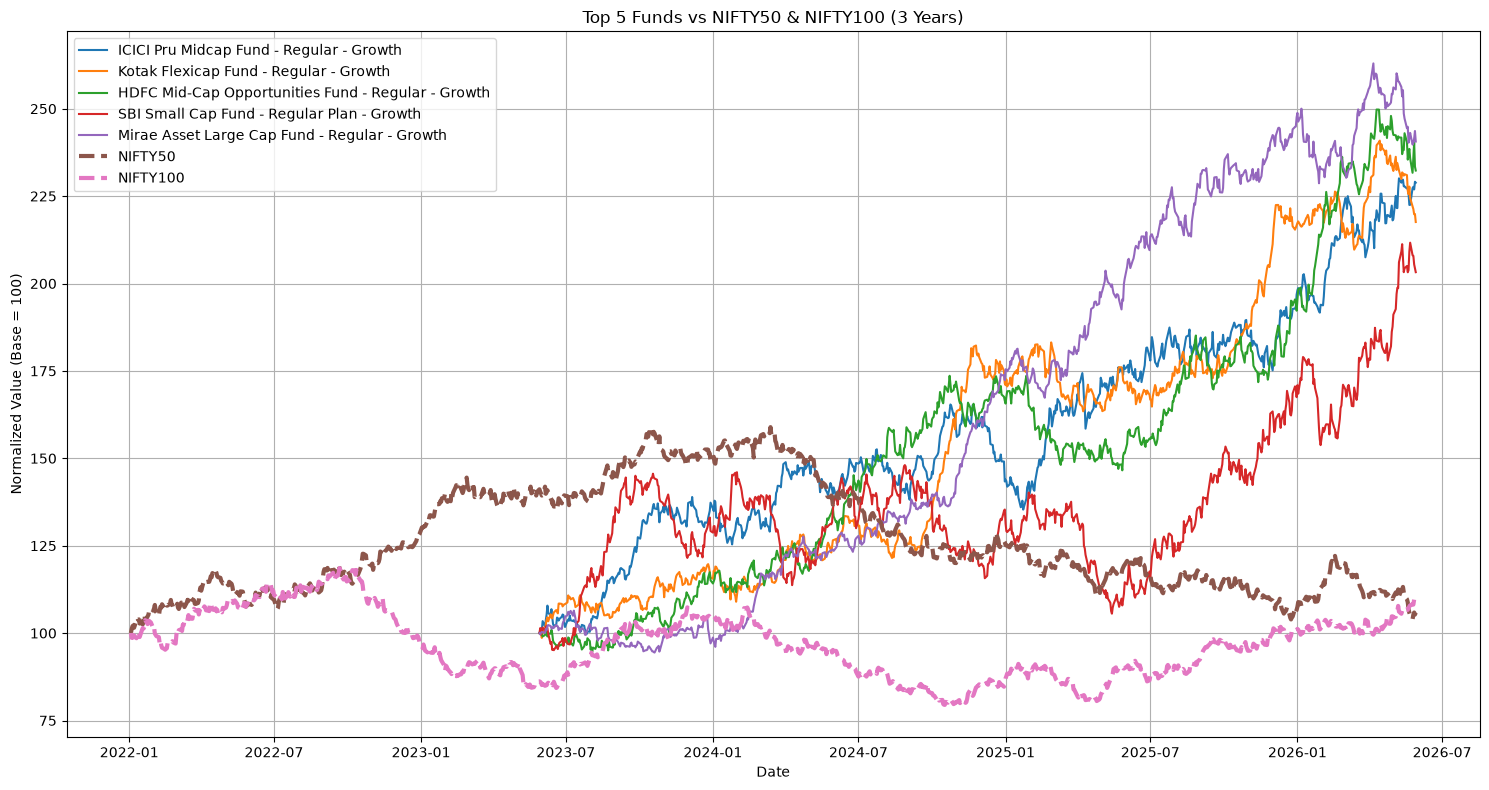

In [ ]:
plt.figure(figsize=(15,8))

# Plot funds
for code in top5_codes:

    fund = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    name = scorecard.loc[
        scorecard["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund["date"],
        fund["Normalized_NAV"],
        label=name
    )

# Plot benchmarks
for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark[
        benchmark["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["Normalized_Index"],
        linestyle="--",
        linewidth=3,
        label=index
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [ ]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [ ]:
tracking_error = []

for code in top5_codes:

    fund = top5_nav[
        ["date", "amfi_code", "daily_return"]
    ]

    fund = fund[
        fund["amfi_code"] == code
    ]

    merged = fund.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date"
    )

    te = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking_error.append({
        "amfi_code": code,
        "Tracking_Error": te
    })

tracking_error_df = pd.DataFrame(tracking_error)

In [ ]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)